# พยากรณ์การยกเลิกใช้บริการของลูกค้าธนาคาร (Bank Customer Churn Prediction)

### ปัญหาคืออะไร?

ในธุรกิจธนาคาร ต้นทุนในการหาลูกค้าใหม่ (Customer Acquisition Cost) สูงกว่าการรักษาลูกค้าเก่าถึง 5-25 เท่า ปัญหาคือธนาคารมักไม่รู้ล่วงหน้าว่าลูกค้าคนไหนกำลังจะย้ายค่ายหรือปิดบัญชี โปรเจคนี้จึงมุ่งสร้างโมเดลทำนายโอกาสที่ลูกค้าจะยกเลิกบริการ (Churn) เพื่อให้ธนาคารสามารถเสนอโปรโมชั่นหรือสิทธิพิเศษเพื่อรั้งตัวลูกค้ากลุ่มเสี่ยงไว้ได้ทันท่วงที

### Dataset มาจากไหน และมีความน่าเชื่อถืออย่างไร?
ชุดข้อมูล Churn_Modelling จาก Kaggle ซึ่งเป็นข้อมูลพฤติกรรมการใช้งานจริงของลูกค้าธนาคารกว่า 10,000 รายในยุโรป มีความน่าเชื่อถือและครอบคลุมมิติข้อมูลที่หลากหลาย ทั้งข้อมูลประชากรศาสตร์และพฤติกรรมทางการเงิน

### Features แต่ละตัวมีความหมายยังไง?


*   CreditScore: คะแนนเครดิตของลูกค้า (ยิ่งสูงยิ่งความเสี่ยงทางการเงินต่ำ)
*   Geography / Gender / Age: ประเทศที่อยู่, เพศ, และอายุ
*   Geography / Gender / Age: ประเทศที่อยู่, เพศ, และอายุ

*   Tenure: จำนวนปีที่เป็นลูกค้าของธนาคารมา
*   Balance: ยอดเงินคงเหลือในบัญชี

*   NumOfProducts: จำนวนผลิตภัณฑ์ของธนาคารที่ใช้งานอยู่ (เช่น มีทั้งบัญชีออมทรัพย์และบัตรเครดิต)
*   IsActiveMember: สถานะความเคลื่อนไหวของบัญชี (1=เคลื่อนไหว, 0=ไม่เคลื่อนไหว)

*   Exited (Target): สถานะการปิดบัญชี (1=ปิดบัญชีหนีไปแล้ว, 0=ยังเป็นลูกค้าอยู่)


### ทำไม Machine Learning ถึงเหมาะกับปัญหานี้?

ปัจจัยที่ทำให้ลูกค้าปิดบัญชีมีความซับซ้อน เช่น "ลูกค้าอายุมาก + เงินในบัญชีสูง + ไม่ค่อยเคลื่อนไหวบัญชี" อาจจะมีโอกาสหนีสูง การใช้กฎ If-Else ธรรมดาไม่สามารถครอบคลุมทุกความน่าจะเป็นได้ การใช้ ML จะช่วยดึง Pattern ที่ซ่อนอยู่นี้ออกมาคำนวณเป็นเปอร์เซ็นต์ความเสี่ยง (Probability) ได้อย่างแม่นยำ

--- 📊 สัดส่วนของลูกค้าที่ปิดบัญชี (0=อยู่, 1=หนี) ---
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64


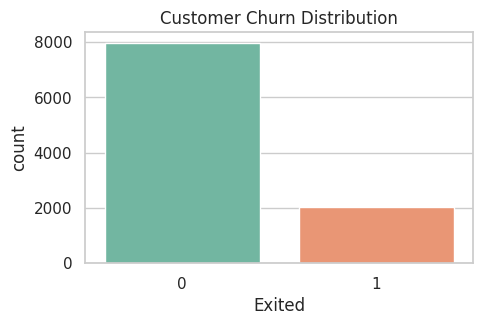


--- 🏆 กำลังเปรียบเทียบ 3 โมเดล... ---

ตารางเปรียบเทียบประสิทธิภาพโมเดล:
              Model  Accuracy  Recall (หาคนหนีเจอ)
  Gradient Boosting     0.869             0.493857
      Random Forest     0.859             0.444717
Logistic Regression     0.808             0.186732

--- ⚙️ จูน Hyperparameter สำหรับ Gradient Boosting ---
✓ Best parameters: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 100}

--- 📈 ผลการประเมินโมเดลสุดท้าย ---
              precision    recall  f1-score   support

    Stay (0)       0.88      0.96      0.92      1593
  Exited (1)       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

✅ บันทึกโมเดล 'churn_model.pkl' สำหรับทำ Streamlit เรียบร้อยแล้ว!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# ==========================================
# 1. โหลดข้อมูลและ EDA เบื้องต้น (กระชับ)
# ==========================================
df = pd.read_csv('Churn_Modelling.csv')
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("--- 📊 สัดส่วนของลูกค้าที่ปิดบัญชี (0=อยู่, 1=หนี) ---")
print(df['Exited'].value_counts(normalize=True).round(3) * 100)

# (เก็บไว้พล็อตโชว์อาจารย์รูปเดียวพอ ไม่ต้องพล็อตเยอะ)
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='Exited', palette='Set2')
plt.title('Customer Churn Distribution')
plt.show()

# ==========================================
# 2. สร้าง Pipeline และแบ่งข้อมูล
# ==========================================
X = df.drop('Exited', axis=1)
y = df['Exited']

# ระบุประเภทคอลัมน์
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'HasCrCard', 'IsActiveMember']
categorical_features = ['Geography', 'Gender']

# สร้าง ColumnTransformer (ตรงตามเกณฑ์หมวด 2)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# แบ่ง Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. โบนัส! เปรียบเทียบ 3 โมเดล (รันทีเดียวจบ)
# ==========================================
print("\n--- 🏆 กำลังเปรียบเทียบ 3 โมเดล... ---")
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall (หาคนหนีเจอ)': recall_score(y_test, y_pred) # เน้น Recall
    })

results_df = pd.DataFrame(results).sort_values(by='Recall (หาคนหนีเจอ)', ascending=False)
# ใช้ print แทน display เพื่อป้องกัน Error ในบาง Environment
print("\nตารางเปรียบเทียบประสิทธิภาพโมเดล:")
print(results_df.to_string(index=False))

# ==========================================
# 4. จูน Hyperparameter ตัวที่ดีที่สุด (Gradient Boosting)
# ==========================================
print("\n--- ⚙️ จูน Hyperparameter สำหรับ Gradient Boosting ---")
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# ย่อ Grid ให้เล็กลง จะได้รันเร็วๆ ตอนโชว์อาจารย์
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    best_pipeline, param_grid, cv=StratifiedKFold(n_splits=5), scoring='recall', n_jobs=-1
)
grid_search.fit(X_train, y_train)

final_model = grid_search.best_estimator_
y_pred_final = final_model.predict(X_test)

print(f"✓ Best parameters: {grid_search.best_params_}")

# ==========================================
# 5. สรุปผลลัพธ์และเซฟโมเดล
# ==========================================
print("\n--- 📈 ผลการประเมินโมเดลสุดท้าย ---")
print(classification_report(y_test, y_pred_final, target_names=['Stay (0)', 'Exited (1)']))

# เซฟโมเดลเตรียมทำเว็บ
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("✅ บันทึกโมเดล 'churn_model.pkl' สำหรับทำ Streamlit เรียบร้อยแล้ว!")